## Coffee Disease Predictions

### Importing Libraries

In [48]:
import os
import math
import random
import shutil
from PIL import Image
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt

# Scikit-learn for data splitting and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

# PyTorch for deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset

# Transformers for pre-trained models
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights



### Set the random seed

###### This makes your results more reproducible.

In [49]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

### Selecting Device

In [50]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)

GPU: NVIDIA GeForce RTX 4070 Laptop GPU
CUDA Version: 13.0


### Dataset Structure

Total Dataset
│
├── Training Set (70%)
│   └── Model learns from these images
│
└── Evaluation Set (30%)
    │
    ├── Validation Set (15%)
    │   └── Model selection / hyperparameter tuning
    │
    └── Test Set (15%)
        └── Final performance evaluation

### Load the complete dataset

In [51]:
dataset = datasets.ImageFolder(
    root='Dataset'
)

print(f"Classes: {dataset.classes}")

print(f"\nClass Mapping: {dataset.class_to_idx}")

print(f"\nTotal images: {len(dataset)}")

Classes: ['Health', 'Leaf Rust', 'Phoma']

Class Mapping: {'Health': 0, 'Leaf Rust': 1, 'Phoma': 2}

Total images: 3220


### Checking and Moving Bad Image files

In [52]:
dataset_folder = "Dataset"
bad_folder = "Dataset_Bad_Images"

os.makedirs(bad_folder, exist_ok=True)

bad_images = []

# Find corrupted images
for root, dirs, files in os.walk(dataset_folder):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(root, file)

            try:
                with Image.open(path) as img:
                    img.verify()
            except Exception:
                bad_images.append(path)

print(f"Found {len(bad_images)} bad images.")

# Move bad images
for path in bad_images:
    filename = os.path.basename(path)

    # Keep original class folder in the destination
    class_name = os.path.basename(os.path.dirname(path))
    class_folder = os.path.join(bad_folder, class_name)

    os.makedirs(class_folder, exist_ok=True)

    destination = os.path.join(class_folder, filename)

    shutil.move(path, destination)

    print(f"Moved: {path}")

print("\nDone!")
print(f"Total images moved: {len(bad_images)}")

Found 0 bad images.

Done!
Total images moved: 0


### Checking the Number of Images per class

In [53]:
targets = np.array(dataset.targets)

class_names = dataset.classes
num_classes = len(class_names)

class_counts = Counter(targets)

print("Number of images per class:\n")

for class_id in range(num_classes):
    print(
        f"{class_names[class_id]:15s}: "
        f"{class_counts[class_id]:,}"
    )

Number of images per class:

Health         : 1,079
Leaf Rust      : 1,031
Phoma          : 1,110


### Visualize the number of Images

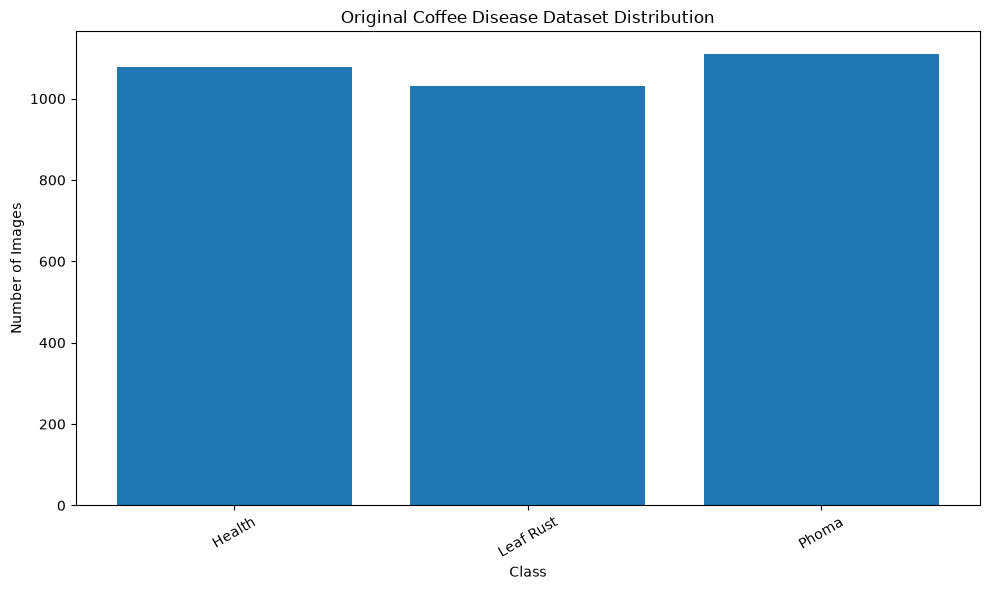

In [54]:
plt.figure(figsize=(10, 6))

counts = [
    class_counts[i]
    for i in range(num_classes)
]

plt.bar(class_names, counts)

plt.title("Original Coffee Disease Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Stratified Train / Validation / Test split
##### The stratify parameter ensures that all five classes are represented proportionally.
###### Training: 70%, Validation: 20%, Test: 10%

In [55]:
targets = np.array(dataset.targets)

Split_Data = np.arange(len(dataset))

Training_Set, Evaluation_Set = train_test_split(
    Split_Data,
    test_size=0.20,
    stratify=targets,
    random_state=SEED
)

Validation_Set, Test_Set = train_test_split(
    Evaluation_Set,
    test_size=0.20,
    stratify=targets[Evaluation_Set],
    random_state=SEED
)

### Check the number of images in the Split Data

In [56]:
class_names = list(dataset.class_to_idx.keys())

print("\nClass Distribution:")

for name, indices in [
    ("Training", Training_Set),
    ("Validation", Validation_Set),
    ("Testing", Test_Set)
]:

    split_targets = targets[indices]
    split_counts = Counter(split_targets)

    print(f"\n{name}:")

    for class_name, class_id in dataset.class_to_idx.items():

        print(
            f"{class_name:15s}: "
            f"{split_counts[class_id]:,}"
        )


Class Distribution:

Training:
Health         : 863
Leaf Rust      : 825
Phoma          : 888

Validation:
Health         : 173
Leaf Rust      : 165
Phoma          : 177

Testing:
Health         : 43
Leaf Rust      : 41
Phoma          : 45


### Save Test Images

In [57]:
test_images_dir = "test_images"

for class_name in dataset.class_to_idx.keys():
    os.makedirs(os.path.join(test_images_dir, class_name), exist_ok=True)

for index in Test_Set:
    image_path, label = dataset.samples[index]
    class_name = dataset.classes[label]
    destination = os.path.join(test_images_dir, class_name, os.path.basename(image_path))
    shutil.copy2(image_path, destination)

print(f"Test images saved to: {test_images_dir}")

Test images saved to: test_images


### Define image transformations

 ##### Training Image Tranformation

In [58]:
train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomVerticalFlip(p=0.2),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

##### Validation/Testing Image Transformation

In [59]:
test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Create datasets with different transformations

In [60]:
class SubsetWithTransform(Dataset):

    def __init__(
        self,
        dataset,
        indices,
        transform=None
    ):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):

        original_idx = self.indices[idx]

        image_path, label = self.dataset.samples[original_idx]

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

### Creating the Transformed (Training, Validation and Testing Dataset)

In [61]:
train_dataset = SubsetWithTransform(
    dataset,
    Training_Set,
    transform=train_transform
)

val_dataset = SubsetWithTransform(
    dataset,
    Validation_Set,
    transform=test_transform
)

test_dataset = SubsetWithTransform(
    dataset,
    Test_Set,
    transform=test_transform
)

### Calculate class weights

In [62]:
num_classes = len(class_names)

# train_targets contains the class label of every image in your training set.

train_targets = targets[Training_Set]

train_class_counts = Counter(train_targets)

class_weights = {}

for class_id in range(num_classes):

    class_weights[class_id] = (
        1.0 /train_class_counts[class_id]
    )

# Print class weights
print("\nClass Weights:")

for class_id in range(num_classes):

    print(
        f"{class_names[class_id]:15s}: "
        f"{class_weights[class_id]:.8f}"
    )


Class Weights:
Health         : 0.00115875
Leaf Rust      : 0.00121212
Phoma          : 0.00112613


### Create a weight for every training image

In [63]:
sample_weights = np.array([
    class_weights[label]
    for label in train_targets
])
sample_weights = torch.DoubleTensor(
    sample_weights
)

### Create the WeightedRandomSampler

In [64]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

### Create DataLoaders

In [65]:
batch_size = 32
num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

print("Classes:", class_names)
print("Class mapping:", train_dataset.dataset.class_to_idx)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))


Classes: ['Health', 'Leaf Rust', 'Phoma']
Class mapping: {'Health': 0, 'Leaf Rust': 1, 'Phoma': 2}
Training samples: 2576
Validation samples: 515
Testing samples: 129


### Building Convolutional Neural Networks (CNNs) 

In [ ]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.linear_relu_stack = nn.Sequential(

            nn.Linear(224*224*3, 512),
            nn.ReLU(),
           
            nn.Linear(512,256),
            nn.ReLU(),
            
            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,3)
        )


    def forward(self,x):

        x = self.flatten(x)

        logits = self.linear_relu_stack(x)

        return logits

CNN_model = NeuralNetwork().to(device)


### Calling Transfer Learning Models

#### 1_Resnet 18

In [78]:
resnet18_weights = ResNet18_Weights.DEFAULT

resnet18_model = resnet18(
    weights=resnet18_weights
)

resnet18_model.fc = nn.Linear(
    resnet18_model.fc.in_features, num_classes
)

resnet18_model = resnet18_model.to(device)


#### 3_EfficientNet-B0

In [68]:
efficientnet_weights = EfficientNet_B0_Weights.DEFAULT

efficientnet_model = efficientnet_b0(
    weights=efficientnet_weights
)

efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_model.classifier[1].in_features,
    num_classes
)

efficientnet_model = efficientnet_model.to(device)

#### 5_MobileNetV3-Large

In [69]:

mobilenet_weights = MobileNet_V3_Large_Weights.DEFAULT

mobilenet_model = mobilenet_v3_large(
    weights=mobilenet_weights
)

mobilenet_model.classifier[3] = nn.Linear(
    mobilenet_model.classifier[3].in_features,
    num_classes
)

mobilenet_model = mobilenet_model.to(device)

### Defining Optimizer parameters and Loss Function

In [70]:
epochs = 20
patience = 3
learning_rate = 0.0001
loss_fn = nn.CrossEntropyLoss()

### Creating an optimizer for each model

In [71]:
optimizer_cnn = optim.Adam(
    CNN_model.parameters(),
    lr=learning_rate
)

optimizer_resnet18 = optim.Adam(
    resnet18_model.parameters(),
    lr=learning_rate
)

optimizer_efficientnet = optim.Adam(
    efficientnet_model.parameters(),
    lr=learning_rate
)
optimizer_mobilenet = optim.Adam(
    mobilenet_model.parameters(),
    lr=learning_rate
)

### Defining Model and Optimizer

In [72]:
models = {
    "CNN": CNN_model,
    "ResNet18": resnet18_model,
    "EfficientNet": efficientnet_model,
    "MobileNet": mobilenet_model
}

optimizers = {
    "CNN": optimizer_cnn,
    "ResNet18": optimizer_resnet18,
    "EfficientNet": optimizer_efficientnet,
    "MobileNet": optimizer_mobilenet
}

### Model Training Function

In [73]:
def train_loop(train_loader, model, loss_fn, optimizer, epoch, total_epochs):
    size = len(train_loader.dataset)
    model.train()

    train_loss = 0.0
    correct = 0

    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f"Epoch [{epoch}/{total_epochs}]",
        leave=True,
        bar_format="{desc} |{bar}| {n_fmt}/{total_fmt}"
    )

    for batch, (X, y) in progress_bar:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X.size(0)
        correct += (pred.argmax(dim=1) == y).sum().item()

        if batch % 10 == 0:
            current = min((batch + 1) * X.size(0), size)

            progress_bar.set_description(
                f"Epoch [{epoch}/{total_epochs}] "
                f"Loss: {loss.item():.4f} "
                f"[{current}/{size}]"
            )

    train_loss /= size
    train_acc = correct / size

    return train_loss, train_acc

### Model Evaluation Function

In [74]:
def val_loop(val_loader, model, loss_fn):
    size = len(val_loader.dataset)
    model.eval()

    val_loss = 0.0
    correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            pred = model(X)
            loss = loss_fn(pred, y)

            predictions = pred.argmax(dim=1)

            val_loss += loss.item() * X.size(0)
            correct += (predictions == y).sum().item()

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    val_loss /= size
    val_acc = correct / size

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return val_loss, val_acc, precision, recall, f1

### Model Training/Saving

In [ ]:
os.makedirs("models", exist_ok=True)

results = []

for model_name, model in models.items():

    print(f"\nTraining {model_name}")

    optimizer = optimizers[model_name]

    best_f1 = 0.0
    patience_counter = 0

    for epoch in range(epochs):

        train_loss, train_acc = train_loop(
            train_loader,
            model,
            loss_fn,
            optimizer,
            epoch + 1,
            epochs
        )

        val_loss, val_acc, val_precision, val_recall, val_f1 = val_loop(
            val_loader,
            model,
            loss_fn
        )

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Precision: {val_precision:.4f} | "
            f"Recall: {val_recall:.4f} | "
            f"F1: {val_f1:.4f}"
        )

        if val_f1 > best_f1:

            best_f1 = val_f1
            patience_counter = 0

            torch.save(
                model.state_dict(),
                f"models/best_{model_name}.pth"
                )

            print(
                f"Best {model_name} saved: "
                f"F1 = {val_f1:.4f}"
            )

        else:

            patience_counter += 1

            print(
                f"No improvement "
                f"({patience_counter}/{patience})"
            )

            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    results.append({
        "Model": model_name,
        "Accuracy": val_acc*100,
        "Precision": val_precision*100,
        "Recall": val_recall*100,
        "F1 Score": val_f1*100
    })


Training CNN


Epoch [1/20] Loss: 0.4655 [1296/2576]:  |██████████| 81/81


Train Loss: 0.9025 | Train Acc: 0.6266 | Val Loss: 0.5640 | Val Acc: 0.7534 | Precision: 0.7502 | Recall: 0.7542 | F1: 0.7484
Best CNN saved: F1 = 0.7484


Epoch [2/20] Loss: 0.8863 [1296/2576]:  |██████████| 81/81


Train Loss: 0.6588 | Train Acc: 0.7143 | Val Loss: 0.5336 | Val Acc: 0.7786 | Precision: 0.7792 | Recall: 0.7782 | F1: 0.7751
Best CNN saved: F1 = 0.7751


...

Train Loss: 0.0286 | Train Acc: 0.9884 | Val Loss: 0.0121 | Val Acc: 0.9961 | Precision: 0.9960 | Recall: 0.9962 | F1: 0.9961
No improvement (1/3)


Epoch [7/20] Loss: 0.0016 [1296/2576]:  |██████████| 81/81


Train Loss: 0.0187 | Train Acc: 0.9938 | Val Loss: 0.0135 | Val Acc: 0.9922 | Precision: 0.9922 | Recall: 0.9923 | F1: 0.9922
No improvement (2/3)


Epoch [8/20] Loss: 0.0029 [1296/2576]:  |██████████| 81/81


Train Loss: 0.0327 | Train Acc: 0.9884 | Val Loss: 0.0082 | Val Acc: 0.9981 | Precision: 0.9980 | Recall: 0.9981 | F1: 0.9980
No improvement (3/3)
Early stopping triggered.


### Model Performance Report

In [76]:

results = pd.DataFrame(results)

results = results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results = results.round(2)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,MobileNet,99.81,99.80,99.81,99.80
1,EfficientNet,99.61,99.61,99.61,99.61
2,ResNet18,99.22,99.21,99.25,99.22
3,CNN,85.24,85.97,84.96,84.82


### Model Performance Graph

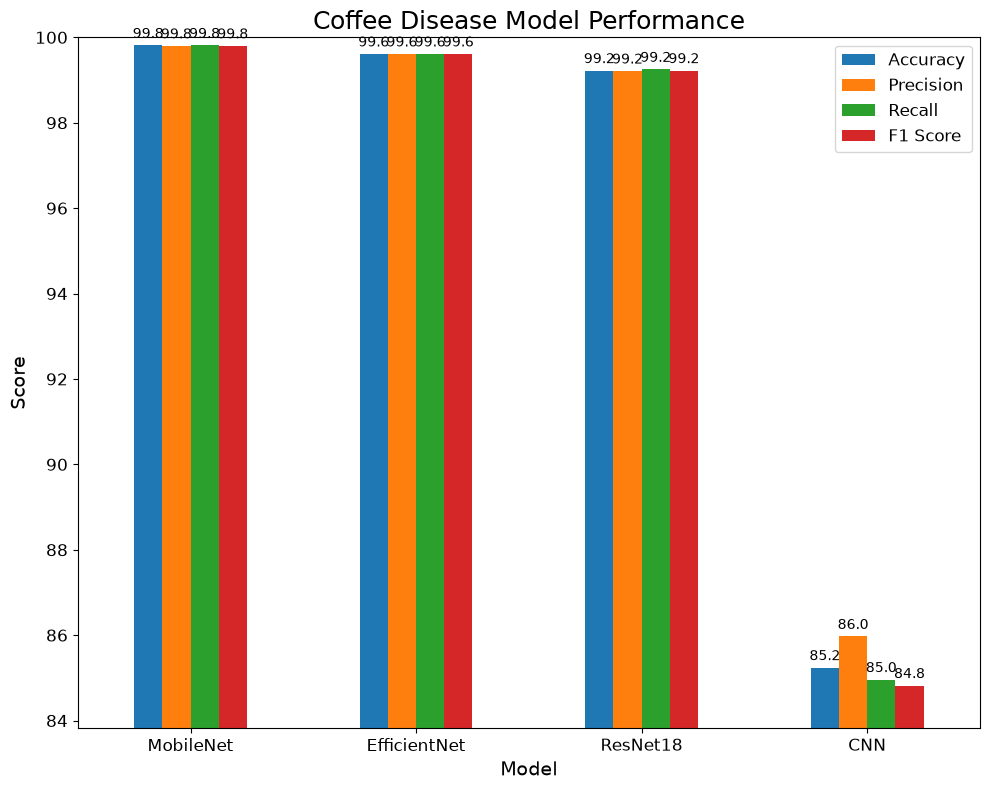

In [77]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

ax = results.plot(
    x="Model",
    y=metrics,
    kind="bar",
    figsize=(10, 8)
)

min_score = results[metrics].min().min()
max_score = results[metrics].max().max()

plt.ylim(
    max(0, min_score - 1),
    min(100, max_score + 1)
)

plt.xlabel("Model", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.title("Coffee Disease Model Performance", fontsize=18)

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.show()